<a href="https://colab.research.google.com/github/gsaivarshini10/qubit-efficient-hybrid-quantum-reinforcement-learning-for-vrp/blob/main/qrl2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pennylane torch matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.0 MB/s eta 0:00:00


Ep    1 | dist   430.527 | return  -430.527 | adv     0.000 | mem  2661.1 MB | no_improve 0
Ep    2 | dist   444.926 | return  -444.926 | adv   -12.959 | mem  4173.5 MB | no_improve 1
Ep    3 | dist   433.490 | return  -433.490 | adv    -1.371 | mem  4451.8 MB | no_improve 2
Ep    4 | dist   442.017 | return  -442.017 | adv    -8.908 | mem  4451.8 MB | no_improve 3
Ep    5 | dist   408.589 | return  -408.589 | adv    22.068 | mem  4451.8 MB | no_improve 0
Ep    6 | dist   439.818 | return  -439.818 | adv    -8.245 | mem  4451.8 MB | no_improve 1
Ep    7 | dist   420.147 | return  -420.147 | adv    10.284 | mem  4451.8 MB | no_improve 2
Ep    8 | dist   480.775 | return  -480.775 | adv   -45.310 | mem  4451.8 MB | no_improve 3
Ep    9 | dist   441.058 | return  -441.058 | adv    -5.034 | mem  4451.8 MB | no_improve 4
Ep   10 | dist   473.510 | return  -473.510 | adv   -33.737 | mem  4451.8 MB | no_improve 5
Ep   11 | dist   467.612 | return  -467.612 | adv   -25.055 | mem  4451.8 MB | n

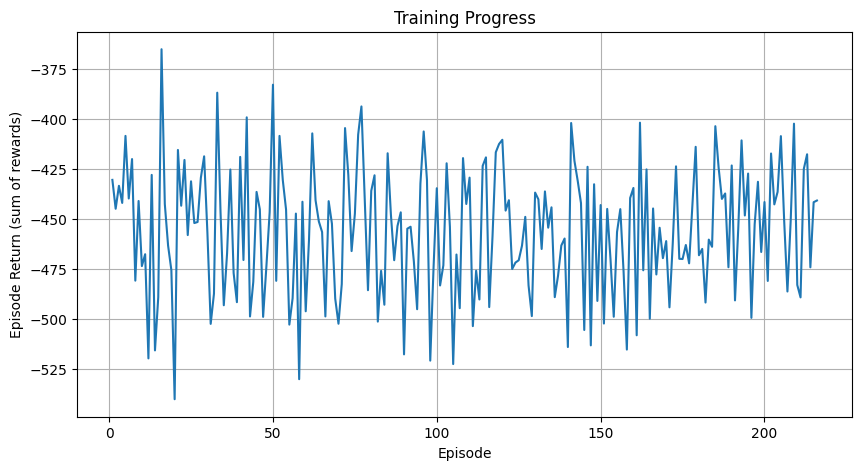

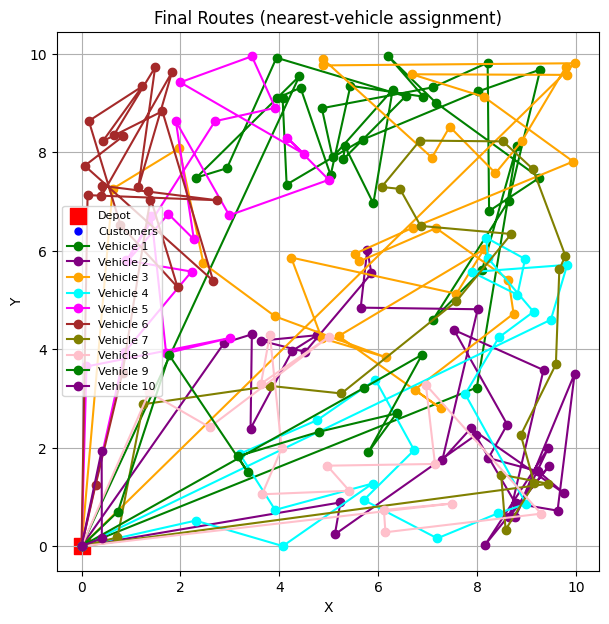

In [ ]:
"""
-------------------MAIN-------------------

Hybrid QRL for VRP (scaled to 20–30 vehicles, 100–200 locations)
- Classical attention encoder (customer self-attention)
- Quantum modulation (PennyLane) **batched over customers**
- REINFORCE with moving-average baseline (episode-level)
- Adaptive early stopping
- Nearest-vehicle assignment (vehicle is NOT chosen by policy)

Key scaling changes vs your original:
1) Policy outputs a distribution over CUSTOMERS only (size = C)
2) Vehicle is assigned as nearest vehicle to selected customer (O(V))
3) Quantum circuit is evaluated in a BATCH (O(C) per step), not O(V*C)

This keeps 6 qubits feasible for C=100..200, V=20..30 on CPU (still not fast, but not impossible).
"""

import os
import random
import psutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import matplotlib.pyplot as plt

# -------------------------------
# REPRODUCIBILITY (optional)
# -------------------------------
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

# -------------------------------
# VRP ENVIRONMENT
# -------------------------------
class VRPEnvironment:
    """
    Simplified multi-vehicle "visit all customers" environment.
    - Vehicles start at depot (0,0)
    - Action: choose (vehicle_idx, customer_idx)
    - Reward: -distance traveled for that step
    - Done: when all customers visited

    NOTE: This is not a full VRP (no capacity, no time windows, etc.).
    """
    def __init__(self, customers, num_vehicles=2):
        self.depot = np.array([0.0, 0.0])
        self.customers = np.array(customers, dtype=float)
        self.num_customers = len(self.customers)
        self.num_vehicles = num_vehicles
        self.reset()

    def reset(self):
        self.visited = np.zeros(self.num_customers, dtype=bool)
        self.vehicle_positions = np.tile(self.depot, (self.num_vehicles, 1)).astype(float)
        self.total_distance = 0.0
        return self._get_state()

    def _distance(self, a, b):
        return np.linalg.norm(a - b)

    def _get_state(self):
        return np.concatenate([
            self.vehicle_positions.flatten(),
            self.customers.flatten(),
            self.visited.astype(float)
        ])

    def step(self, vehicle_idx, customer_idx):
        if self.visited[customer_idx]:
            # penalize invalid (revisit)
            return self._get_state(), -5.0, all(self.visited), 0.0
        curr = self.vehicle_positions[vehicle_idx]
        target = self.customers[customer_idx]
        dist = self._distance(curr, target)
        self.vehicle_positions[vehicle_idx] = target.copy()
        self.visited[customer_idx] = True
        self.total_distance += dist
        done = all(self.visited)
        reward = -dist
        return self._get_state(), reward, done, dist

# -------------------------------
# QUANTUM CIRCUIT (BATCHED)
# -------------------------------
n_qubits = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def q_policy_qnode_batched(encoded_angles, q_weights):
    """
    encoded_angles: shape [C, n_qubits] (batched) or [n_qubits] (single)
    returns: shape [C] (if batched) or scalar (if single)
    """
    for i in range(n_qubits):
        qml.RY(encoded_angles[..., i], wires=i)  # broadcasting
    for i in range(n_qubits):
        qml.RY(q_weights[i, 0], wires=i)
        qml.RZ(q_weights[i, 1], wires=i)
        qml.RX(q_weights[i, 2], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    qml.CNOT(wires=[n_qubits - 1, 0])
    return qml.expval(qml.PauliZ(0))

# -------------------------------
# HYBRID QRL POLICY (CUSTOMER-ONLY)
# -------------------------------
class HybridQRLPolicyCustomerOnly(nn.Module):
    """
    Outputs probs over customers (C).
    Vehicles are assigned outside policy by nearest-vehicle rule.
    """
    def __init__(self, embed_dim=128, n_heads=4, n_qubits_local=n_qubits):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_qubits = n_qubits_local

        # customer input features:
        # (x, y, visited_flag, nearest_vehicle_dist_norm) => 4 dims
        self.customer_embed = nn.Sequential(
            nn.Linear(4, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

        # customer self-attention
        self.self_attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)

        # classical logits head
        self.logit_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1),
        )

        # quantum path: per-customer angles
        self.classical_to_qubits = nn.Linear(embed_dim, self.n_qubits)
        self.q_weights = nn.Parameter(0.01 * torch.randn(self.n_qubits, 3, dtype=torch.float32))

        # quantum output -> logit contribution
        self.q_to_logit = nn.Linear(1, 1)

    def forward(self, vehicle_positions_np, customer_positions_np, visited_mask_np):
        device = next(self.parameters()).device

        vehicle_positions = torch.tensor(vehicle_positions_np, dtype=torch.float32, device=device)  # [V,2]
        customers = torch.tensor(customer_positions_np, dtype=torch.float32, device=device)        # [C,2]
        visited = torch.tensor(visited_mask_np, dtype=torch.float32, device=device)               # [C]

        C = customers.shape[0]

        # nearest-vehicle distance feature per customer (cheap classical)
        # cdist: [C,V]
        d = torch.cdist(customers, vehicle_positions)
        nearest_dist = d.min(dim=1).values  # [C]
        nearest_dist = nearest_dist / (nearest_dist.max() + 1e-8)
        nearest_dist = nearest_dist.unsqueeze(1)  # [C,1]

        cust_in = torch.cat([customers, visited.unsqueeze(1), nearest_dist], dim=1)  # [C,4]
        emb = self.customer_embed(cust_in)  # [C,E]

        # self attention over customers (batch=1)
        attn_out, _ = self.self_attn(emb.unsqueeze(0), emb.unsqueeze(0), emb.unsqueeze(0))  # [1,C,E]
        attn_out = attn_out.squeeze(0)  # [C,E]

        # classical logits
        classical_logits = self.logit_head(attn_out).squeeze(-1)  # [C]

        # quantum logits (BATCHED over customers)
        angles = torch.tanh(self.classical_to_qubits(attn_out)) * np.pi  # [C, n_qubits]
        q = q_policy_qnode_batched(angles, self.q_weights).to(torch.float32)  # [C]
        q_logits = self.q_to_logit(q.unsqueeze(1)).squeeze(1)  # [C]

        logits = classical_logits + q_logits

        # mask visited
        logits = logits.masked_fill(visited >= 0.5, -1e9)

        probs = torch.softmax(logits, dim=0)  # [C]
        return probs

# -------------------------------
# TRAINING WITH EARLY STOPPING (SCALED)
# -------------------------------
def train_hybrid_qrl_scaled(
    customers,
    num_vehicles=30,
    max_episodes=2000,
    patience=200,
    lr=3e-4,
    device="cpu",
    grad_clip=1.0,
    verbose=True,
):
    env = VRPEnvironment(customers, num_vehicles=num_vehicles)
    policy = HybridQRLPolicyCustomerOnly(embed_dim=128, n_heads=4, n_qubits_local=n_qubits).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    best_distance = float("inf")
    best_route = None
    rewards_hist = []
    mem_usage_records = []
    no_improve = 0
    baseline = None  # moving-average baseline on returns

    for ep in range(1, max_episodes + 1):
        env.reset()
        done = False
        route_log = [[] for _ in range(num_vehicles)]
        log_probs = []
        step_rewards = []

        # At most one pick per customer if we always mask visited properly
        for _ in range(env.num_customers):
            vehicle_positions = env.vehicle_positions.copy()
            customer_positions = env.customers.copy()
            visited_mask = env.visited.astype(float)

            probs = policy(vehicle_positions, customer_positions, visited_mask)

            # guard against numerical issues
            if torch.isnan(probs).any() or probs.sum().item() <= 0:
                break

            # sample customer from probs
            c = torch.multinomial(probs, 1).item()
            log_probs.append(torch.log(probs[c] + 1e-8))

            # nearest vehicle assignment (your "nearest vehicle selection" but now it's the only vehicle choice)
            customer_pos = env.customers[c]
            distances = [env._distance(pos, customer_pos) for pos in env.vehicle_positions]
            v = int(np.argmin(distances))

            _, r, done, _ = env.step(v, c)
            step_rewards.append(r)
            route_log[v].append(f"C{c+1}")

            if done:
                break

        # episode return (sum of step rewards = - total distance traversed by vehicles, not including return to depot)
        G = float(np.sum(step_rewards))
        rewards_hist.append(G)

        # moving-average baseline to reduce REINFORCE variance
        baseline = G if baseline is None else (0.9 * baseline + 0.1 * G)
        advantage = G - baseline

        if len(log_probs) > 0:
            # maximize return => minimize negative objective
            loss = -(advantage) * torch.stack(log_probs).sum()
            optimizer.zero_grad()
            loss.backward()
            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip)
            optimizer.step()

        # memory usage
        mem_mb = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
        mem_usage_records.append(mem_mb)

        # early stopping based on best total distance achieved
        if env.total_distance < best_distance:
            best_distance = env.total_distance
            best_route = route_log
            no_improve = 0
        else:
            no_improve += 1

        if verbose:
            print(
                f"Ep {ep:4d} | dist {env.total_distance:9.3f} | return {G:9.3f} "
                f"| adv {advantage:9.3f} | mem {mem_mb:7.1f} MB | no_improve {no_improve}"
            )

        if no_improve >= patience:
            print(f"\nStopping early at episode {ep} (no improvement in {patience} episodes)")
            break

    avg_mem = float(np.mean(mem_usage_records)) if len(mem_usage_records) else 0.0
    return policy, best_route, best_distance, rewards_hist, avg_mem

# -------------------------------
# VISUALIZATION
# -------------------------------
def plot_training(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(rewards) + 1), rewards)
    plt.xlabel("Episode")
    plt.ylabel("Episode Return (sum of rewards)")
    plt.title("Training Progress")
    plt.grid(True)
    plt.show()

def plot_vrp_route(customers, route_log):
    plt.figure(figsize=(7, 7))
    depot = np.array([0.0, 0.0])
    plt.scatter(*depot, c="red", marker="s", s=120, label="Depot")
    cust_array = np.array(customers, dtype=float)
    plt.scatter(cust_array[:, 0], cust_array[:, 1], c="blue", s=25, label="Customers")

    colors = ["green", "purple", "orange", "cyan", "magenta", "brown", "olive", "pink"]
    for v_idx, route in enumerate(route_log):
        if not route:
            continue
        positions = [depot] + [customers[int(r[1:]) - 1] for r in route] + [depot]
        positions = np.array(positions, dtype=float)
        plt.plot(
            positions[:, 0],
            positions[:, 1],
            marker="o",
            linewidth=1.5,
            color=colors[v_idx % len(colors)],
            label=f"Vehicle {v_idx + 1}",
        )

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Final Routes (nearest-vehicle assignment)")
    plt.legend(loc="best", fontsize=8)
    plt.grid(True)
    plt.show()

# -------------------------------
# DATA GENERATION (for 100/200 customers)
# -------------------------------
def make_customers(n_customers=200, coord_low=0.0, coord_high=10.0, seed=0):
    rng = np.random.default_rng(seed)
    pts = rng.uniform(coord_low, coord_high, size=(n_customers, 2))
    return [tuple(p) for p in pts]

# -------------------------------
# MAIN
# -------------------------------
if __name__ == "__main__":
    set_seed(0)

    # Choose either:
    # A) your original small set (works, but doesn't test scaling)
    # customers = [
    #     (2, 3), (5, 4), (6, 1), (3, 6), (4, 2),
    #     (0, 1), (10, 5), (1, 1), (2, 4), (4, 4)
    # ]

    # B) scaled set: 100 or 200 customers
    customers = make_customers(n_customers=200, coord_low=0.0, coord_high=10.0, seed=0)

    num_vehicles = 30

    policy, best_route, best_distance, rewards, avg_mem = train_hybrid_qrl_scaled(
        customers=customers,
        num_vehicles=num_vehicles,
        max_episodes=2000,
        patience=200,
        lr=3e-4,
        device="cpu",
        grad_clip=1.0,
        verbose=True,
    )

    # Save the trained model
    save_path = "hybrid_qrl_policy_scaled.pth"
    torch.save(policy.state_dict(), save_path)
    full_path = os.path.abspath(save_path)
    print(f"\n✅ Hybrid QRL model saved successfully at: {full_path}")

    print("\n=== Training Finished ===")
    print(f"Best Distance: {best_distance:.3f}")
    print(f"Average Memory Usage: {avg_mem:.2f} MB")
    print(f"Vehicles: {num_vehicles} | Customers: {len(customers)}")

    # Plot
    plot_training(rewards)
    if best_route is not None:
        plot_vrp_route(customers, best_route)

✅ Loaded saved model from: /content/hybrid_qrl_policy_scaled.pth
Ep    1 | dist   402.711 | return  -402.711 | adv     0.000 | mem  4951.6 MB | no_improve 0
Ep    2 | dist   358.229 | return  -358.229 | adv    40.034 | mem  5214.3 MB | no_improve 0
Ep    3 | dist   449.352 | return  -449.352 | adv   -45.981 | mem  5207.0 MB | no_improve 1
Ep    4 | dist   394.930 | return  -394.930 | adv     7.598 | mem  5207.0 MB | no_improve 2
Ep    5 | dist   383.548 | return  -383.548 | adv    17.081 | mem  5207.0 MB | no_improve 3
Ep    6 | dist   407.392 | return  -407.392 | adv    -6.086 | mem  5207.0 MB | no_improve 4
Ep    7 | dist   421.615 | return  -421.615 | adv   -18.279 | mem  5207.0 MB | no_improve 5
Ep    8 | dist   462.652 | return  -462.652 | adv   -53.384 | mem  5207.0 MB | no_improve 6
Ep    9 | dist   432.185 | return  -432.185 | adv   -20.625 | mem  5207.0 MB | no_improve 7
Ep   10 | dist   394.606 | return  -394.606 | adv    15.258 | mem  5207.0 MB | no_improve 8
Ep   11 | dist 

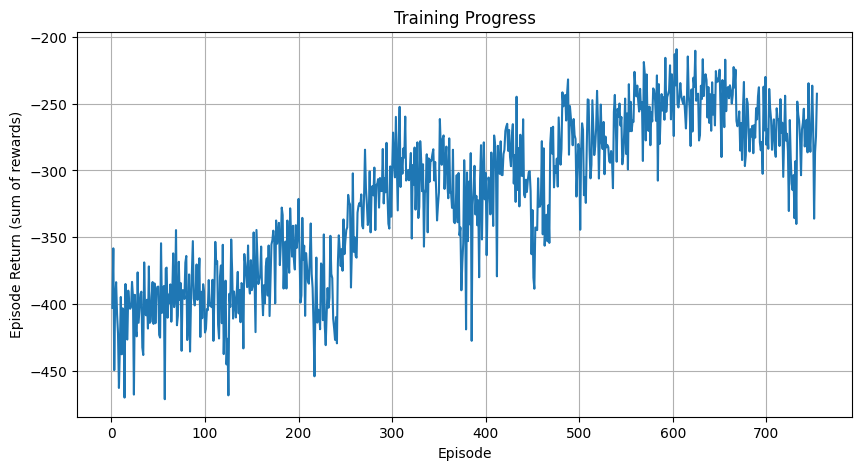

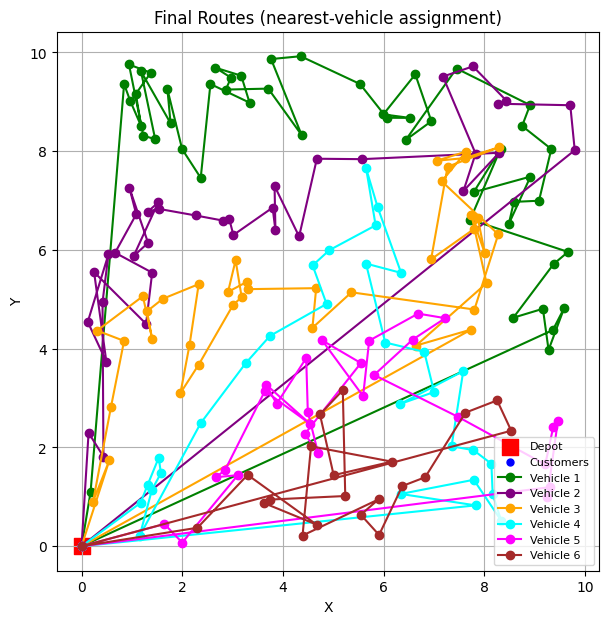

In [ ]:
import os
import torch
import numpy as np

# -----------------------------
# Generate 200 customer locations
# -----------------------------
def make_customers(n_customers=200, coord_low=0.0, coord_high=10.0, seed=42):
    rng = np.random.default_rng(seed)
    pts = rng.uniform(coord_low, coord_high, size=(n_customers, 2))
    return [tuple(p) for p in pts]

new_customers = make_customers(n_customers=200)
new_num_vehicles = 20
device = "cpu"

# -----------------------------
# Initialize scaled policy
# -----------------------------
policy = HybridQRLPolicyCustomerOnly(
    embed_dim=128,
    n_heads=4,
    n_qubits_local=6
).to(device)

saved_model_path = "/content/hybrid_qrl_policy_scaled.pth"

# -----------------------------
# Load previous weights (if exist)
# -----------------------------
if os.path.exists(saved_model_path):
    policy.load_state_dict(torch.load(saved_model_path, map_location=device))
    print(f"✅ Loaded saved model from: {saved_model_path}")
else:
    print("⚠️ Saved model not found. Training from scratch.")

# -----------------------------
# Train / Fine-Tune
# -----------------------------
policy, best_route, best_distance, rewards, avg_mem = train_hybrid_qrl_scaled(
    customers=new_customers,
    num_vehicles=new_num_vehicles,
    max_episodes=1500,
    patience=150,
    lr=3e-4,          # lower LR for stability at scale
    device=device,
    grad_clip=1.0,
    verbose=True
)

# -----------------------------
# Save updated model
# -----------------------------
torch.save(policy.state_dict(), saved_model_path)
print(f"\n✅ Fine-tuned model saved at: {os.path.abspath(saved_model_path)}")

# -----------------------------
# Results
# -----------------------------
print("\n=== Large-Scale Fine-Tuning Finished ===")
print(f"Vehicles: {new_num_vehicles}")
print(f"Customers: {len(new_customers)}")
print(f"Best Distance: {best_distance:.3f}")
print(f"Average Memory Usage: {avg_mem:.2f} MB")

plot_training(rewards)
plot_vrp_route(new_customers, best_route)

✅ Loaded trained scaled model for testing.

=== Test Finished ===
Vehicle 1 route: Depot -> C135 -> C26 -> C88 -> C82 -> C75 -> C14 -> C68 -> C9 -> C145 -> C175 -> C146 -> C70 -> C115 -> C196 -> C102 -> C129 -> C147 -> C25 -> C151 -> C176 -> C18 -> C56 -> C8 -> C181 -> C42 -> C133 -> C13 -> C166 -> C37 -> C95 -> C186 -> C96 -> C174 -> C199 -> C22 -> C67 -> C83 -> C156 -> C200 -> C74 -> C162 -> C143 -> C124 -> C11 -> C138 -> C41 -> C183 -> C71 -> C178 -> C152 -> C29 -> C31 -> C44 -> C1 -> C110 -> C189 -> C153 -> C192 -> C161 -> C69 -> C72 -> C184 -> C163 -> C117 -> C59 -> C108 -> C53 -> C80 -> C28 -> C7 -> C2 -> C51 -> C4 -> C179 -> C123 -> C99 -> C126 -> C173 -> C90 -> C121 -> C167 -> C191 -> C23 -> C84 -> C118 -> C140 -> C149 -> C12 -> Depot
Vehicle 2 route: Depot -> C43 -> C120 -> C182 -> C30 -> C109 -> C136 -> C141 -> C188 -> C49 -> C94 -> C155 -> C134 -> C132 -> C64 -> C142 -> C100 -> C157 -> C127 -> C24 -> C187 -> C54 -> C73 -> C158 -> C17 -> C92 -> C34 -> C165 -> C47 -> C125 -> C

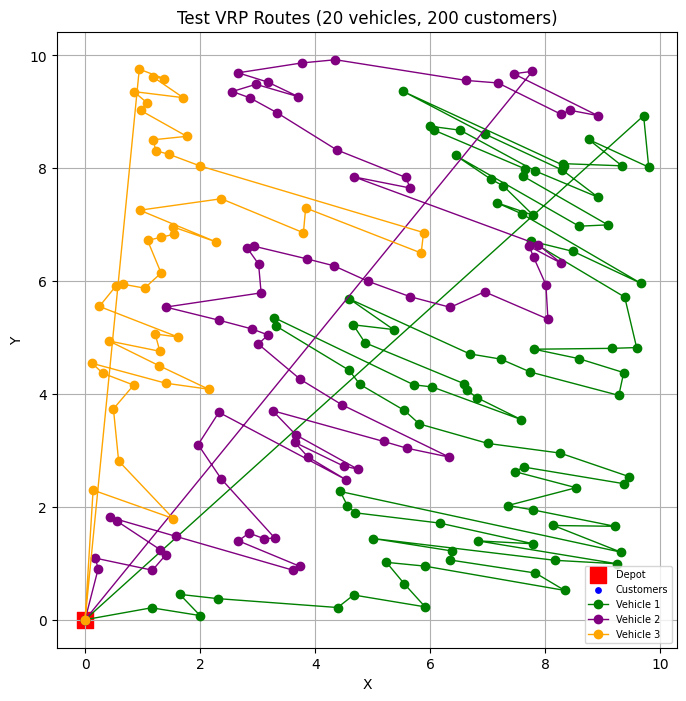

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

device = "cpu"

# -----------------------------
# Create / load test dataset (200 locations)
# IMPORTANT: match the distribution you trained on (range + seed)
# -----------------------------
def make_customers(n_customers=200, coord_low=0.0, coord_high=10.0, seed=42):
    rng = np.random.default_rng(seed)
    pts = rng.uniform(coord_low, coord_high, size=(n_customers, 2))
    return [tuple(p) for p in pts]

test_customers = make_customers(n_customers=200, coord_low=0.0, coord_high=10.0, seed=42)
num_test_vehicles = 20

# -----------------------------
# Load scaled policy
# -----------------------------
policy = HybridQRLPolicyCustomerOnly(embed_dim=128, n_heads=4, n_qubits_local=6).to(device)
model_path = "/content/hybrid_qrl_policy_scaled.pth"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found at: {model_path}. Train and save it first.")

policy.load_state_dict(torch.load(model_path, map_location=device))
policy.eval()
print("✅ Loaded trained scaled model for testing.")

# -----------------------------
# Test Environment (same as train env)
# -----------------------------
class VRPEnvironmentTest:
    def __init__(self, customers, num_vehicles):
        self.depot = np.array([0.0, 0.0])
        self.customers = np.array(customers, dtype=float)
        self.num_customers = len(customers)
        self.num_vehicles = num_vehicles
        self.reset()

    def reset(self):
        self.visited = np.zeros(self.num_customers, dtype=bool)
        self.vehicle_positions = np.tile(self.depot, (self.num_vehicles, 1)).astype(float)
        self.total_distance = 0.0
        return self._get_state()

    def _distance(self, a, b):
        return np.linalg.norm(a - b)

    def _get_state(self):
        return np.concatenate([
            self.vehicle_positions.flatten(),
            self.customers.flatten(),
            self.visited.astype(float)
        ])

    def step(self, vehicle_idx, customer_idx):
        if self.visited[customer_idx]:
            return self._get_state(), -5.0, all(self.visited), 0.0
        curr = self.vehicle_positions[vehicle_idx]
        target = self.customers[customer_idx]
        dist = self._distance(curr, target)
        self.vehicle_positions[vehicle_idx] = target.copy()
        self.visited[customer_idx] = True
        self.total_distance += dist
        done = all(self.visited)
        reward = -dist
        return self._get_state(), reward, done, dist

# -----------------------------
# Run 1 test episode
# decode = "greedy" or "sample"
# -----------------------------
decode = "greedy"  # change to "sample" if you want stochastic test

env = VRPEnvironmentTest(test_customers, num_test_vehicles)
route_log = [[] for _ in range(num_test_vehicles)]
done = False
steps = 0

env.reset()

while not done and steps < env.num_customers:
    vehicle_positions = env.vehicle_positions.copy()
    customer_positions = env.customers.copy()
    visited_mask = env.visited.astype(float)

    with torch.no_grad():
        probs = policy(vehicle_positions, customer_positions, visited_mask)  # shape [C]

    probs_np = probs.cpu().numpy()
    probs_np = np.maximum(probs_np, 0)
    if probs_np.sum() == 0:
        break
    probs_np /= probs_np.sum()

    # choose customer
    if decode == "greedy":
        customer_idx = int(np.argmax(probs_np))
    elif decode == "sample":
        customer_idx = int(np.random.choice(len(probs_np), p=probs_np))
    else:
        raise ValueError("decode must be 'greedy' or 'sample'")

    # nearest vehicle assignment
    customer_pos = env.customers[customer_idx]
    distances = [env._distance(pos, customer_pos) for pos in env.vehicle_positions]
    vehicle_idx = int(np.argmin(distances))

    _, _, done, _ = env.step(vehicle_idx, customer_idx)
    route_log[vehicle_idx].append(f"C{customer_idx+1}")
    steps += 1

print("\n=== Test Finished ===")
for v_idx, route in enumerate(route_log):
    if len(route) == 0:
        print(f"Vehicle {v_idx+1} route: Depot -> Depot")
    else:
        print(f"Vehicle {v_idx+1} route: Depot -> {' -> '.join(route)} -> Depot")
print(f"Total Distance (no depot return cost in env): {env.total_distance:.3f}")

# -----------------------------
# Plot (warning: 20 vehicles makes clutter)
# -----------------------------
def plot_vrp_route(customers, route_log):
    plt.figure(figsize=(8, 8))
    depot = np.array([0, 0])
    plt.scatter(*depot, c="red", marker="s", s=120, label="Depot")
    cust_array = np.array(customers)
    plt.scatter(cust_array[:, 0], cust_array[:, 1], c="blue", s=15, label="Customers")

    colors = ["green", "purple", "orange", "cyan", "magenta", "brown", "olive", "pink"]
    for v_idx, route in enumerate(route_log):
        if not route:
            continue
        positions = [depot] + [customers[int(r[1:]) - 1] for r in route] + [depot]
        positions = np.array(positions)
        plt.plot(
            positions[:, 0],
            positions[:, 1],
            marker="o",
            linewidth=1.0,
            color=colors[v_idx % len(colors)],
            label=f"Vehicle {v_idx+1}"
        )

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Test VRP Routes (20 vehicles, 200 customers)")
    plt.legend(loc="best", fontsize=7)
    plt.grid(True)
    plt.show()

plot_vrp_route(test_customers, route_log)